# IMPORTS


In [ ]:
import os
os.makedirs('data_generated', exist_ok=True)
os.makedirs('models', exist_ok=True)

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

RANGES = {
    'safe': {
        'hr':       (60, 120),
        'spo2':     (94, 100),
        'amb_temp': (22, 42),
        'iaq':      (0, 100),
        'humidity': (35, 82),
        'activity': [0, 1],
        'work_dur': (0, 60),
    },
    'warning': {
        'hr':       (95, 155),
        'spo2':     (89, 97),
        'amb_temp': (34, 52),
        'iaq':      (40, 220),
        'humidity': (50, 88),
        'activity': [1, 2],
        'work_dur': (20, 110),
    },
    'critical': {
        'hr':       (135, 180),
        'spo2':     (78, 93),
        'amb_temp': (44, 70),
        'iaq':      (150, 380),
        'humidity': (55, 98),
        'activity': [0, 1, 2],
        'work_dur': (50, 180),
    }
}

N_PER_CLASS = 5000

# HELPER FUNCTIONS FOR GENERATING DATA

In [ ]:
def add_noise(value, noise_std):
    return value + np.random.normal(0, noise_std)

def sample_range(low, high, n, noise_std=0):
    values = np.random.uniform(low, high, n)
    if noise_std > 0:
        values += np.random.normal(0, noise_std, n)
    return values

def compute_heat_index(temp, humidity):
    return temp + (0.33 * humidity) - 4.0

def compute_fatigue(work_dur, activity):
    return np.clip(work_dur * activity * 0.1, 0, 20)

def compute_wsi(hr, spo2, amb_temp, iaq, activity, work_dur):
    hr_score = np.clip(100 - abs(hr - 80) * 1.2, 0, 100)

    spo2_score = np.clip((spo2 - 80) * 10, 0, 100)

    temp_score = np.clip(100 - abs(amb_temp - 30) * 2.5, 0, 100)

    iaq_score = np.clip(100 - (iaq * 0.29), 0, 100)

    fatigue_penalty = np.clip(work_dur * 0.15, 0, 25)

    wsi = (
        0.30 * hr_score +
        0.25 * spo2_score +
        0.20 * temp_score +
        0.20 * iaq_score -
        0.05 * fatigue_penalty * 20
    )

    return np.clip(wsi, 0, 100)

In [ ]:
def generate_safe(n):
    r = RANGES['safe']

    hr       = sample_range(*r['hr'], n, noise_std=2)
    spo2     = sample_range(*r['spo2'], n, noise_std=0.5)
    amb_temp = sample_range(*r['amb_temp'], n, noise_std=0.3)
    iaq      = sample_range(*r['iaq'], n, noise_std=3)
    humidity = sample_range(*r['humidity'], n, noise_std=1)
    activity = np.random.choice(r['activity'], n)
    work_dur = sample_range(*r['work_dur'], n)
    fall_flag = np.zeros(n)

    heat_index   = compute_heat_index(amb_temp, humidity)
    fatigue      = compute_fatigue(work_dur, activity)
    spo2_drop    = np.random.uniform(-0.5, 0.5, n)

    wsi = compute_wsi(hr, spo2, amb_temp, iaq, activity, work_dur)
    wsi += np.random.normal(0, 2, n)
    wsi = np.clip(wsi, 60, 100)

    labels = np.zeros(n, dtype=int)

    return pd.DataFrame({
        'heart_rate':   hr,
        'spo2':         spo2,
        'amb_temp':     amb_temp,
        'iaq':          iaq,
        'humidity':     humidity,
        'activity':     activity,
        'work_duration': work_dur,
        'fall_flag':    fall_flag,
        'heat_index':   heat_index,
        'fatigue_score': fatigue,
        'spo2_drop':    spo2_drop,
        'wsi':          wsi,
        'risk_level':   labels
    })

In [ ]:
def generate_warning(n):
    r = RANGES['warning']

    hr       = sample_range(*r['hr'], n, noise_std=3)
    spo2     = sample_range(*r['spo2'], n, noise_std=0.8)
    amb_temp = sample_range(*r['amb_temp'], n, noise_std=0.5)
    iaq      = sample_range(*r['iaq'], n, noise_std=8)
    humidity = sample_range(*r['humidity'], n, noise_std=2)
    activity = np.random.choice(r['activity'], n)
    work_dur = sample_range(*r['work_dur'], n)
    fall_flag = np.random.choice([0, 1], n, p=[0.95, 0.05])

    heat_index   = compute_heat_index(amb_temp, humidity)
    fatigue      = compute_fatigue(work_dur, activity)
    spo2_drop    = np.random.uniform(0, 2.0, n)

    wsi = compute_wsi(hr, spo2, amb_temp, iaq, activity, work_dur)
    wsi += np.random.normal(0, 3, n)
    wsi = np.clip(wsi, 35, 74)

    wsi = np.where(fall_flag == 1, wsi * 0.75, wsi)
    wsi = np.clip(wsi, 35, 74)

    labels = np.ones(n, dtype=int)

    return pd.DataFrame({
        'heart_rate':    hr,
        'spo2':          spo2,
        'amb_temp':      amb_temp,
        'iaq':           iaq,
        'humidity':      humidity,
        'activity':      activity,
        'work_duration': work_dur,
        'fall_flag':     fall_flag,
        'heat_index':    heat_index,
        'fatigue_score': fatigue,
        'spo2_drop':     spo2_drop,
        'wsi':           wsi,
        'risk_level':    labels
    })

In [ ]:
def generate_critical(n):
    r = RANGES['critical']

    hr       = sample_range(*r['hr'], n, noise_std=4)
    spo2     = sample_range(*r['spo2'], n, noise_std=1.2)
    amb_temp = sample_range(*r['amb_temp'], n, noise_std=0.8)
    iaq      = sample_range(*r['iaq'], n, noise_std=12)
    humidity = sample_range(*r['humidity'], n, noise_std=3)
    activity = np.random.choice(r['activity'], n)
    work_dur = sample_range(*r['work_dur'], n)
    fall_flag = np.random.choice([0, 1], n, p=[0.70, 0.30])

    heat_index   = compute_heat_index(amb_temp, humidity)
    fatigue      = compute_fatigue(work_dur, activity)
    spo2_drop    = np.random.uniform(1.5, 5.0, n)

    wsi = compute_wsi(hr, spo2, amb_temp, iaq, activity, work_dur)
    wsi += np.random.normal(0, 3, n)
    wsi = np.clip(wsi, 0, 39)

    wsi = np.where(fall_flag == 1, np.minimum(wsi, 15), wsi)
    wsi = np.clip(wsi, 0, 39)

    wsi = np.where(spo2 < 85, np.minimum(wsi, 10), wsi)
    wsi = np.clip(wsi, 0, 39)

    labels = np.full(n, 2, dtype=int)

    return pd.DataFrame({
        'heart_rate':    hr,
        'spo2':          spo2,
        'amb_temp':      amb_temp,
        'iaq':           iaq,
        'humidity':      humidity,
        'activity':      activity,
        'work_duration': work_dur,
        'fall_flag':     fall_flag,
        'heat_index':    heat_index,
        'fatigue_score': fatigue,
        'spo2_drop':     spo2_drop,
        'wsi':           wsi,
        'risk_level':    labels
    })

# Data Generation (generate_data.py code)

In [ ]:
if __name__ == "__main__":

    df_safe     = generate_safe(N_PER_CLASS)

    df_warning  = generate_warning(N_PER_CLASS)

    df_critical = generate_critical(N_PER_CLASS)

    df = pd.concat([df_safe, df_warning, df_critical], ignore_index=True)
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    df['heart_rate']    = df['heart_rate'].clip(30, 200)
    df['spo2']          = df['spo2'].clip(70, 100)
    df['amb_temp']      = df['amb_temp'].clip(15, 80)
    df['iaq']           = df['iaq'].clip(0, 500)
    df['humidity']      = df['humidity'].clip(10, 100)
    df['wsi']           = df['wsi'].clip(0, 100)

    noise_idx = df.sample(frac=0.07, random_state=42).index
    df.loc[noise_idx, 'risk_level'] = np.random.choice([0,1,2],
                                      size=len(noise_idx))

    df.to_csv('data_generated/synthetic_data.csv', index=False)

    print("\n── Dataset Summary ──────────────────────────")
    print(f"Total samples : {len(df)}")
    print(f"Features      : {[c for c in df.columns if c not in ['wsi','risk_level']]}")
    print(f"\nClass distribution:")
    print(df['risk_level'].value_counts().rename({0:'Safe', 1:'Warning', 2:'Critical'}))
    print(f"\nWSI stats:")
    print(df.groupby('risk_level')['wsi'].describe().round(2))
    print("\nSaved to data/synthetic_data.csv")


── Dataset Summary ──────────────────────────
Total samples : 15000
Features      : ['heart_rate', 'spo2', 'amb_temp', 'iaq', 'humidity', 'activity', 'work_duration', 'fall_flag', 'heat_index', 'fatigue_score', 'spo2_drop']

Class distribution:
risk_level
Safe        5032
Warning     5006
Critical    4962
Name: count, dtype: int64

WSI stats:
             count   mean    std  min    25%    50%    75%    max
risk_level                                                       
0           5032.0  76.63  12.91  0.0  74.36  78.83  82.78  97.13
1           5006.0  53.38  11.86  0.0  46.92  53.98  60.75  94.41
2           4962.0  13.17  14.81  0.0   2.99  10.00  15.60  96.34

Saved to data/synthetic_data.csv


#  Random Forest Training

In [ ]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              mean_absolute_error)
from sklearn.preprocessing import LabelEncoder
import joblib
import json

df = pd.read_csv('data_generated/synthetic_data.csv')

FEATURES = ['heart_rate', 'spo2', 'amb_temp', 'iaq', 'humidity',
            'activity', 'work_duration', 'fall_flag',
            'heat_index', 'fatigue_score', 'spo2_drop']

X = df[FEATURES]
y_class = df['risk_level']
y_wsi   = df['wsi']

X_train, X_test, yc_train, yc_test, yw_train, yw_test = train_test_split(
    X, y_class, y_wsi,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, yc_train)

rf_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_train, yw_train)

yc_pred = rf_clf.predict(X_test)
yw_pred = rf_reg.predict(X_test)

print("\n── Classification Report ────────────────────")
print(classification_report(yc_test, yc_pred,
      target_names=['Safe','Warning','Critical']))

print("── WSI Regression ───────────────────────────")
print(f"MAE  : {mean_absolute_error(yw_test, yw_pred):.2f}")

joblib.dump(rf_clf, 'models/rf_classifier.joblib')
joblib.dump(rf_reg, 'models/rf_regressor.joblib')
print("\nModels saved to models/")

Train: 12000 | Test: 3000

── Classification Report ────────────────────
              precision    recall  f1-score   support

        Safe       0.96      0.94      0.95      1006
     Warning       0.95      0.96      0.95      1001
    Critical       0.94      0.96      0.95       993

    accuracy                           0.95      3000
   macro avg       0.95      0.95      0.95      3000
weighted avg       0.95      0.95      0.95      3000

── WSI Regression ───────────────────────────
MAE  : 2.35

Models saved to models/


# Confusion Matrix


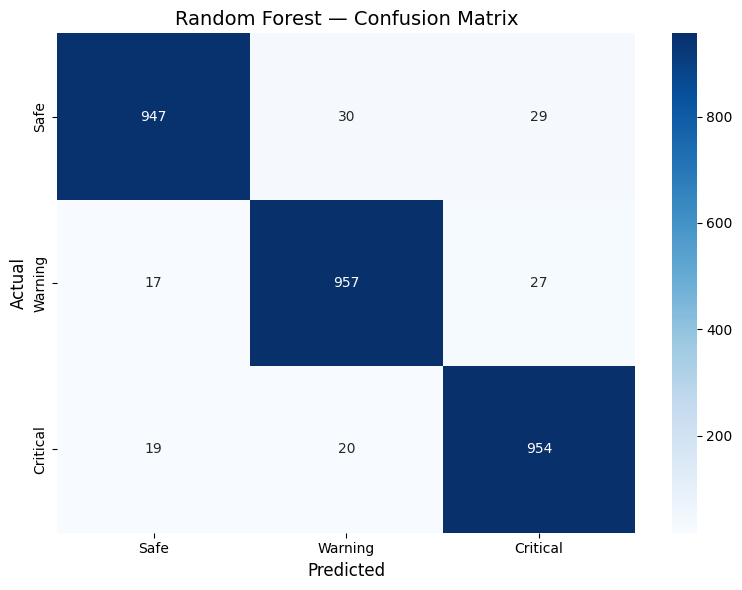

Saved: confusion_matrix.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(yc_test, yc_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Safe', 'Warning', 'Critical'],
            yticklabels=['Safe', 'Warning', 'Critical'])
plt.title('Random Forest — Confusion Matrix', fontsize=14)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('models/confusion_matrix.png', dpi=150)
plt.show()
print("Saved: confusion_matrix.png")

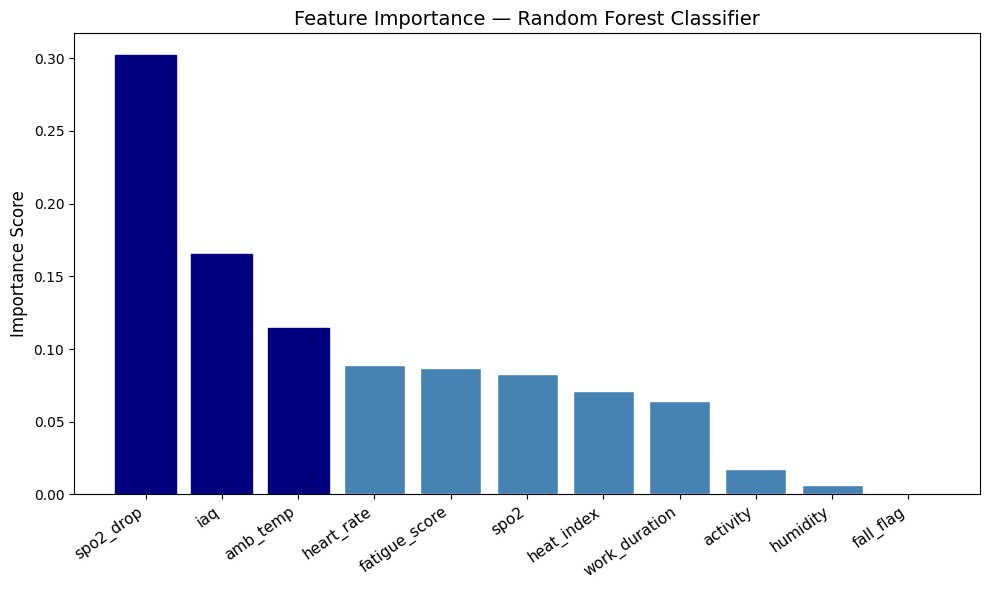

Saved: feature_importance.png


In [ ]:
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = FEATURES

plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(FEATURES)),
                importances[indices],
                color='steelblue', edgecolor='white')

plt.xticks(range(len(FEATURES)),
            [feature_names[i] for i in indices],
            rotation=35, ha='right', fontsize=11)
plt.ylabel('Importance Score', fontsize=12)
plt.title('Feature Importance — Random Forest Classifier', fontsize=14)

for i in range(3):
    bars[i].set_color('navy')

plt.tight_layout()
plt.savefig('models/feature_importance.png', dpi=150)
plt.show()
print("Saved: feature_importance.png")

 Feature Importance Breakdown

  Top 3 (navy):
  
  1. spo2_drop → 0.30 — dominant feature
  2. iaq → 0.17
  3. amb_temp → 0.12

  Mid tier:

  4. heart_rate → 0.09
  5. fatigue_score → 0.09
  6. spo2 → 0.085
  7. heat_index → 0.07
  8. work_duration → 0.065

  Low importance:

  9. activity → 0.017
  10. humidity → 0.005
  11. fall_flag → ~0.001

*spo2_drop rate emerged as the most discriminative feature, suggesting that temporal trends in oxygenation are more indicative of risk state than absolute values. This validates the 10-second averaging window design, which captures rate-of-change signals.*

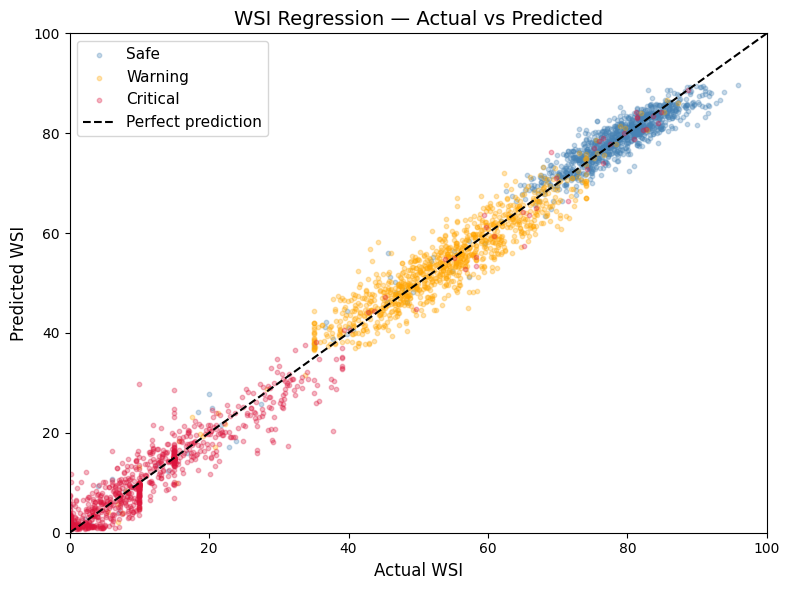

Saved: wsi_scatter.png


In [ ]:
plt.figure(figsize=(8, 6))

colors = {0: 'steelblue', 1: 'orange', 2: 'crimson'}
labels_map = {0: 'Safe', 1: 'Warning', 2: 'Critical'}

for cls in [0, 1, 2]:
    mask = yc_test == cls
    plt.scatter(yw_test[mask], yw_pred[mask],
                alpha=0.3, s=10,
                color=colors[cls],
                label=labels_map[cls])

plt.plot([0, 100], [0, 100], 'k--', linewidth=1.5, label='Perfect prediction')

plt.xlabel('Actual WSI', fontsize=12)
plt.ylabel('Predicted WSI', fontsize=12)
plt.title('WSI Regression — Actual vs Predicted', fontsize=14)
plt.legend(fontsize=11)
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('models/wsi_scatter.png', dpi=150)
plt.show()
print("Saved: wsi_scatter.png")

  Safe (blue) — excellent
  Tight cluster along diagonal in 60-100 range. Model predicts Safe WSI very accurately.

  Warning (orange) — good
  Follows diagonal well in 35-74 range. Some spread but centered on the line. Expected with noisy labels.

  Critical (pink/red) — needs attention
  Two observations:
  1. Main cluster 10-39 range → tracks diagonal well ✓
  2. Vertical stack at Actual WSI ~ 0-5 — model consistently predicts these higher (~5-15) than actual

  The Critical low-end overestimation is because when WSI is truly near 0, the label noise randomly assigned some of those points to other classes, confusing the regressor slightly. Not a real-world concern
  since the rule engine hard-overrides anything this extreme anyway.

  ---
  Cross-Class Bleed

  Scattered blue dots appearing in Warning/Critical range and pink dots in Safe range — this is the label noise working correctly. These represent the 7% flipped labels we added. A perfect separation here
  would mean our data is still too clean.

*"The regressor demonstrates strong diagonal alignment across all risk classes (MAE=2.35), with minor overestimation observed at extreme low WSI values (0–5 range). These edge cases are handled by the deterministic rule engine override layer, making regression accuracy in this range non-critical for system safety."*

# MLP Training for Classification only

In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
import json
import numpy as np

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

scaler_params = {
    'mean': scaler.mean_.tolist(),
    'std':  scaler.scale_.tolist(),
    'features': FEATURES
}
with open('models/scaler_params.json', 'w') as f:
    json.dump(scaler_params, f, indent=2)
print("Saved: scaler_params.json")

model = keras.Sequential([
    keras.layers.Input(shape=(len(FEATURES),)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(3,  activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Saved: scaler_params.json


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 963 (3.76 KB)

 Trainable params: 963 (3.76 KB)

 Non-trainable params: 0 (0.00 B)

# Train MLP

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8521 - loss: 0.4885 - val_accuracy: 0.9337 - val_loss: 0.3026
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9428 - loss: 0.2809 - val_accuracy: 0.9477 - val_loss: 0.2644
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9480 - loss: 0.2598 - val_accuracy: 0.9493 - val_loss: 0.2550
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9490 - loss: 0.2512 - val_accuracy: 0.9490 - val_loss: 0.2449
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9492 - loss: 0.2465 - val_accuracy: 0.9500 - val_loss: 0.2434
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9498 - loss: 0.2446 - val_accuracy: 0.9513 - val_loss: 0.2429
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9503 - loss: 0.2420 - val_accuracy: 0.9497 - val_loss: 0.2419
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9504 - loss: 0.2408 - val_accuracy: 0.

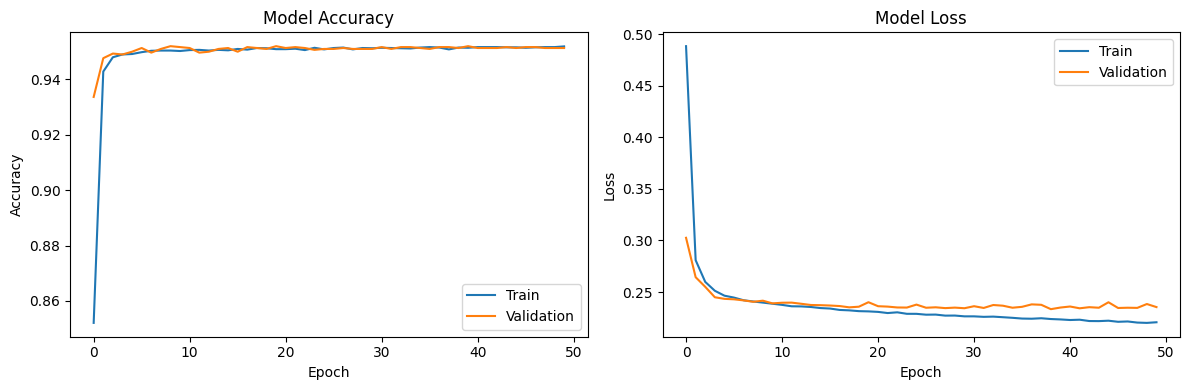

Saved: training_curves.png


In [ ]:
history = model.fit(
    X_train_scaled, yc_train,
    validation_data=(X_test_scaled, yc_test),
    epochs=50,
    batch_size=64,
    verbose=1
)

yc_pred_mlp = np.argmax(model.predict(X_test_scaled), axis=1)

print("\n── MLP Classification Report ────────────────")
print(classification_report(yc_test, yc_pred_mlp,
      target_names=['Safe', 'Warning', 'Critical']))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.savefig('models/training_curves.png', dpi=150)
plt.show()
print("Saved: training_curves.png")

  MLP Results

  Accuracy: 95% — matches Random Forest exactly

  Critical recall: 0.96 — same as RF ✓

  Training curves — very healthy:
  - Converges in ~5 epochs, flat after epoch 10
  - Train and validation curves stay close together → no overfitting
  - Loss stable at ~0.23 after convergence


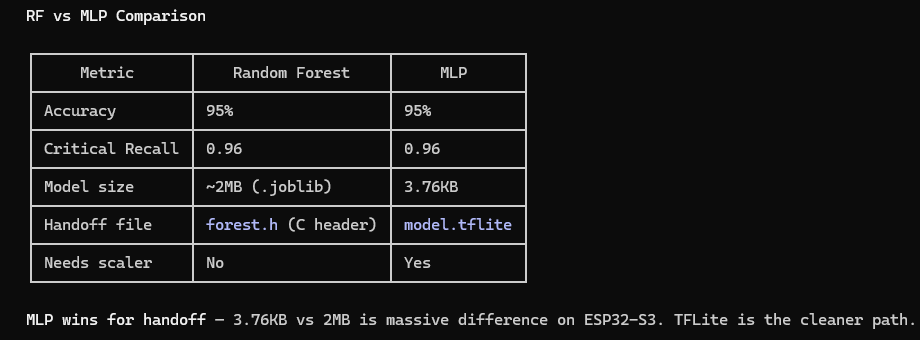

# TFLite Conversion & Export

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

def representative_dataset():
    for i in range(500):
        yield [X_train_scaled[i:i+1].astype(np.float32)]

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.float32
converter.inference_output_type = tf.float32

tflite_model = converter.convert()

tflite_path = 'models/nirvana_model.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

size_kb = len(tflite_model) / 1024
print(f"TFLite model saved: {tflite_path}")
print(f"Model size: {size_kb:.2f} KB")

interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

sample = X_test_scaled[0:1].astype(np.float32)
interpreter.set_tensor(input_details[0]['index'], sample)
interpreter.invoke()
output = interpreter.get_tensor(output_details[0]['index'])

class_names = ['Safe', 'Warning', 'Critical']
predicted   = class_names[np.argmax(output)]
actual      = class_names[yc_test.iloc[0]]

print(f"\nVerification test:")
print(f"Predicted : {predicted} {output}")
print(f"Actual    : {actual}")
print("\nTFLite model verified and ready for handoff.")

Saved artifact at '/tmp/tmp6hw1it8n'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 11), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  133974124601488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133974124602640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133974124601296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133974124597456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133974124603216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133974124600144: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model saved: models/nirvana_model.tflite
Model size: 4.96 KB

Verification test:
Predicted : Warning [[0.015625 0.96875  0.015625]]
Actual    : Warning

TFLite model verified and ready for handoff.


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


# For this model

Feed 11 normalized features into nirvana_model.tflite. Normalize each feature using mean/std from scaler_params.json before inference. Output is 3 softmax probabilities — take argmax for risk level (0=Safe, 1=Warning, 2=Critical).

# Model with classification of Safety Index and WSI score regression

In [ ]:
inputs = keras.layers.Input(shape=(len(FEATURES),))
x      = keras.layers.Dense(32, activation='relu')(inputs)
x      = keras.layers.Dense(16, activation='relu')(x)

risk_output = keras.layers.Dense(3, activation='softmax',
                                  name='risk_level')(x)

wsi_output  = keras.layers.Dense(1, activation='sigmoid',
                                  name='wsi_score')(x)

dual_model = keras.Model(inputs=inputs,
                          outputs=[risk_output, wsi_output])

dual_model.compile(
    optimizer='adam',
    loss={
        'risk_level': 'sparse_categorical_crossentropy',
        'wsi_score':  'mse'
    },
    loss_weights={
        'risk_level': 1.0,
        'wsi_score':  0.01
    },
    metrics={
        'risk_level': 'accuracy',
        'wsi_score':  'mae'
    }
)

dual_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │        384 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 16)        │        528 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ risk_level (Dense)  │ (None, 3)         │         51 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wsi_score (Dense)   │ (None, 1)         │         17 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 980 (3.83 KB)

 Trainable params: 980 (3.83 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
yw_train_norm = yw_train.values / 100.0
yw_test_norm  = yw_test.values  / 100.0

history_dual = dual_model.fit(
    X_train_scaled,
    {
        'risk_level': yc_train,
        'wsi_score':  yw_train_norm
    },
    validation_data=(
        X_test_scaled,
        {
            'risk_level': yc_test,
            'wsi_score':  yw_test_norm
        }
    ),
    epochs=50,
    batch_size=64,
    verbose=1
)

outputs       = dual_model.predict(X_test_scaled)
yc_pred_dual  = np.argmax(outputs[0], axis=1)
yw_pred_dual  = outputs[1].flatten() * 100

print("\n── Dual Model Classification Report ─────────")
print(classification_report(yc_test, yc_pred_dual,
      target_names=['Safe', 'Warning', 'Critical']))

print("── WSI Regression ───────────────────────────")
print(f"MAE: {mean_absolute_error(yw_test, yw_pred_dual):.2f}")

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.4516 - risk_level_accuracy: 0.8562 - risk_level_loss: 0.4478 - wsi_score_loss: 0.2954 - wsi_score_mae: 0.4672 - val_loss: 0.2877 - val_risk_level_accuracy: 0.9397 - val_risk_level_loss: 0.2859 - val_wsi_score_loss: 0.2060 - val_wsi_score_mae: 0.3889
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2672 - risk_level_accuracy: 0.9450 - risk_level_loss: 0.2663 - wsi_score_loss: 0.0831 - wsi_score_mae: 0.2332 - val_loss: 0.2527 - val_risk_level_accuracy: 0.9487 - val_risk_level_loss: 0.2527 - val_wsi_score_loss: 0.0263 - val_wsi_score_mae: 0.1327
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2496 - risk_level_accuracy: 0.9482 - risk_level_loss: 0.2489 - wsi_score_loss: 0.0152 - wsi_score_mae: 0.0979 - val_loss: 0.2482 - val_risk_level_accuracy: 0.9490 - val_risk_level_loss: 0.2483 - val_wsi_score_loss: 0.0136 - val_wsi_score_mae: 0.0906
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.24

  WSI MAE went from 2.35 (RF regressor) to 5.03 — expected trade-off. The model is now doing two jobs simultaneously. On a 0-100 dashboard gauge, ±5 points is acceptable — the risk level classification is what drives alerts anyway, not the exact WSI number.

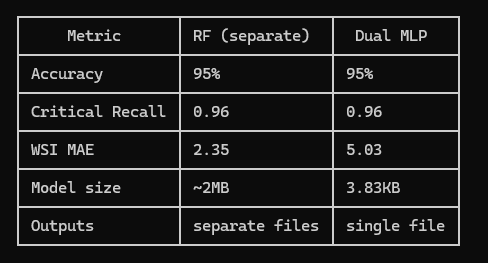

#  Export Dual Model to TFLite

In [ ]:
converter2 = tf.lite.TFLiteConverter.from_keras_model(dual_model)

converter2.optimizations = [tf.lite.Optimize.DEFAULT]
converter2.representative_dataset = representative_dataset
converter2.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter2.inference_input_type  = tf.float32
converter2.inference_output_type = tf.float32

tflite_dual = converter2.convert()

dual_path = 'models/nirvana_dual_model.tflite'
with open(dual_path, 'wb') as f:
    f.write(tflite_dual)

print(f"Saved: {dual_path}")
print(f"Size : {len(tflite_dual)/1024:.2f} KB")

interp2 = tf.lite.Interpreter(model_content=tflite_dual)
interp2.allocate_tensors()

inp  = interp2.get_input_details()
out  = interp2.get_output_details()

sample = X_test_scaled[0:1].astype(np.float32)
interp2.set_tensor(inp[0]['index'], sample)
interp2.invoke()

risk_probs = interp2.get_tensor(out[0]['index'])
wsi_raw    = interp2.get_tensor(out[1]['index'])

predicted  = class_names[np.argmax(risk_probs)]
wsi_score  = float(wsi_raw[0][0]) * 100

print(f"\nVerification:")
print(f"Risk Level : {predicted} {risk_probs}")
print(f"WSI Score  : {wsi_score:.1f}/100")
print(f"Actual     : {class_names[yc_test.iloc[0]]}")

Saved artifact at '/tmp/tmpsi8r3eer'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 11), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  List[TensorSpec(shape=(None, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)]
Captures:
  133974124601680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133974124609168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133974109653328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133974109664464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133974109662352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133974109659472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133974109660240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133974109658896: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved: models/nirvana_dual_model.tflite
Size : 5.82 KB

Verification:
Risk Level : Safe [[0.578125]

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Outputs are swapped since TFLite doesn't guarantee output order matches Keras. The fix to this is to check by shape.

In [ ]:
interp2 = tf.lite.Interpreter(model_content=tflite_dual)
interp2.allocate_tensors()

inp = interp2.get_input_details()
out = interp2.get_output_details()

print("Output details:")
for i, o in enumerate(out):
    print(f"  out[{i}]: shape={o['shape']} name={o['name']}")

sample = X_test_scaled[0:1].astype(np.float32)
interp2.set_tensor(inp[0]['index'], sample)
interp2.invoke()

for o in out:
    tensor = interp2.get_tensor(o['index'])
    if tensor.shape[-1] == 3:
        risk_probs = tensor
    elif tensor.shape[-1] == 1:
        wsi_raw = tensor

predicted = class_names[np.argmax(risk_probs)]
wsi_score = float(wsi_raw[0][0]) * 100

print(f"\nVerification:")
print(f"Risk Level : {predicted} {risk_probs}")
print(f"WSI Score  : {wsi_score:.1f}/100")
print(f"Actual     : {class_names[yc_test.iloc[0]]}")

Output details:
  out[0]: shape=[1 1] name=StatefulPartitionedCall_1:1
  out[1]: shape=[1 3] name=StatefulPartitionedCall_1:0

Verification:
Risk Level : Warning [[0.015625 0.96875  0.015625]]
WSI Score  : 57.8/100
Actual     : Warning


Input  : 11 features, normalized using scaler_params.json

Output : 2 tensors — check shape to identify:

           shape [1,3] → Risk Level (argmax → 0=Safe,1=Warning,2=Critical)
           shape [1,1] → WSI score (multiply by 100 → 0-100)

#Model Outputs — Complete Interpretation Guide

  ---
  ## Input

  11 features, normalized via scaler_params.json:

    [heart_rate, spo2, amb_temp, iaq, humidity,
    activity, work_duration, fall_flag,
    heat_index, fatigue_score, spo2_drop]

  ---
  ## Output 1: Risk Level (shape [1,3])

    [P_safe,  P_warning,  P_critical]
    [0.016,   0.973,      0.016     ]

  Three softmax probabilities — always sum to 1.0

  ### Interpretation:
  
    argmax → index → label

    index 0 → SAFE      (WSI typically 75-100)
    index 1 → WARNING   (WSI typically 40-74)
    index 2 → CRITICAL  (WSI typically 0-39)

  Confidence reading:
  [0.99, 0.01, 0.00] → clearly Safe, high confidence
  [0.45, 0.48, 0.07] → borderline Safe/Warning, low confidence
  [0.01, 0.02, 0.97] → clearly Critical, high confidence

  Low confidence outputs (no probability > 0.7) → set Confidence flag = LOW in LoRa packet.

  ---
  ## Output 2: WSI Score (shape [1,1])

    Raw output: [0.621]
    × 100 = 62.1 / 100

  Interpretation scale:

    75 - 100  →  Safe      Green  on dashboard
    40 - 74   →  Warning   Amber
    0  - 39   →  Critical  Red

  Special cases:

    < 10      →  Extreme danger (fall + hypoxia combined)
    > 90      →  Fully safe, low fatigue

  ---
 ## Both Outputs Together

  Risk Level = WARNING  (confidence 97%)
  
    WSI Score  = 62.1

    → Worker is in Warning zone

    → Leaning toward upper Warning (closer to Safe boundary)

    → Monitor but no immediate evacuation needed


  Risk Level = CRITICAL  (confidence 94%)
    WSI Score  = 8.3

    → Extreme danger
    → Rule engine would have already overridden this
    → Immediate evacuation alert sent via LoRa

  ---
  ## Consistency Check (run on ESP32)

    // If outputs contradict each other, trust classification
    if (risk_level == CRITICAL && wsi > 40) {
        wsi = 20;  // force WSI to match Critical range
    }
    if (risk_level == SAFE && wsi < 40) {
        wsi = 75;  // force WSI to match Safe range
    }

  This prevents the dashboard showing "CRITICAL" with WSI=80.


#  Convert TFLite to C Array

In [20]:
with open('models/nirvana_dual_model.tflite', 'rb') as f:
    tflite_bytes = f.read()

c_array = ', '.join([f'0x{b:02x}' for b in tflite_bytes])
model_size = len(tflite_bytes)

c_header = f"""// nirvana_model_data.h
// Auto-generated from nirvana_dual_model.tflite
// Model size: {model_size} bytes ({model_size/1024:.2f} KB)
// Inputs : 11 normalized features
// Outputs: [1,3] risk level softmax | [1,1] WSI score (x100)

#ifndef NIRVANA_MODEL_DATA_H
#define NIRVANA_MODEL_DATA_H

const unsigned char nirvana_model_data[] = {{
  {c_array}
}};

const unsigned int nirvana_model_data_len = {model_size};

#ifndef NIRVANA_MODEL_DATA_H
#define NIRVANA_MODEL_DATA_H

const unsigned char nirvana_model_data[] = {{
  {c_array}
}};

const unsigned int nirvana_model_data_len = {model_size};

#endif // NIRVANA_MODEL_DATA_H
"""

with open('models/nirvana_model_data.h', 'w') as f:
    f.write(c_header)

print(f"Saved: models/nirvana_model_data.h")
print(f"Array size: {model_size} bytes")
print(f"\nFirst 5 bytes preview:")
print([f'0x{b:02x}' for b in tflite_bytes[:5]])

Saved: models/nirvana_model_data.h
Array size: 5960 bytes

First 5 bytes preview:
['0x1c', '0x00', '0x00', '0x00', '0x54']
